# Weather Condition Classification using SVM and Open-Meteo API

**Assignment 6** - Weather Analytics Classification

## Objective
Classify weather as **Cool** or **Warm** based on meteorological observations from the Open-Meteo API using Support Vector Machine (SVM) classification.

## Task 1: Data Collection and Understanding (2 Marks)

### 1. Fetch weather data using the Open-Meteo API

In [1]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime

# API parameters for London (latitude=51.5074, longitude=-0.1278)
# Using historical data from 2024 for better temperature variation
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 51.5074,
    "longitude": -0.1278,
    "start_date": "2024-01-01",
    "end_date": "2024-12-31",
    "hourly": "temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m",
    "timezone": "UTC"
}

response = requests.get(url, params=params)
data = response.json()

print("Fetching weather data from Open-Meteo Historical API...")
print("Data fetched successfully!")

# Convert to DataFrame
df = pd.DataFrame(data['hourly'])
print(f"Shape of data: {df.shape}")

Fetching weather data from Open-Meteo Historical API...
Data fetched successfully!
Shape of data: (8784, 5)


### 2. Convert the JSON response into a Pandas DataFrame

In [2]:
# DataFrame is already created above
df.head()

,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
0,2024-01-01T00:00,7.6,77,993.1,29.5
1,2024-01-01T01:00,7.4,78,994.2,29.0
2,2024-01-01T02:00,7.0,80,995.1,26.8
3,2024-01-01T03:00,7.0,80,996.1,26.0
4,2024-01-01T04:00,6.8,79,997.1,26.2


### 3. Display the first five records

In [3]:
df.head()

,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
0,2024-01-01T00:00,7.6,77,993.1,29.5
1,2024-01-01T01:00,7.4,78,994.2,29.0
2,2024-01-01T02:00,7.0,80,995.1,26.8
3,2024-01-01T03:00,7.0,80,996.1,26.0
4,2024-01-01T04:00,6.8,79,997.1,26.2


### 4. Identify Input Features and Target Variable

In [4]:
# Create target variable: Weather_Class
df['Weather_Class'] = df['temperature_2m'].apply(lambda x: 'Warm' if x >= 25 else 'Cool')

print("Input Features:")
print("1. temperature_2m - Temperature at 2 meters (°C)")
print("2. relative_humidity_2m - Relative humidity at 2 meters (%)")
print("3. surface_pressure - Surface pressure (hPa)")
print("4. wind_speed_10m - Wind speed at 10 meters (km/h)")
print("\nTarget Variable:")
print("Weather_Class - Created based on temperature:")
print("  - Warm: Temperature ≥ 25°C")
print("  - Cool: Temperature < 25°C")
print(f"\nClass distribution:\n{df['Weather_Class'].value_counts()}")

Input Features:
1. temperature_2m - Temperature at 2 meters (°C)
2. relative_humidity_2m - Relative humidity at 2 meters (%)
3. surface_pressure - Surface pressure (hPa)
4. wind_speed_10m - Wind speed at 10 meters (km/h)

Target Variable:
Weather_Class - Created based on temperature:
  - Warm: Temperature ≥ 25°C
  - Cool: Temperature < 25°C

Class distribution:
Weather_Class
Cool    8683
Warm     101
Name: count, dtype: int64


## Task 2: Data Preprocessing (2 Marks)

### Check for missing values

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)
print("\nNo missing values found!")

Missing values in each column:


time                    0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
wind_speed_10m          0
Weather_Class           0
dtype: int64

No missing values found!


### Remove unnecessary columns

In [6]:
# Remove 'time' column as it's not a useful feature for classification
df_processed = df.drop('time', axis=1)
print("Columns after removing 'time':")
print(df_processed.columns.tolist())

Columns after removing 'time':
['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m', 'Weather_Class']


### Encode the target variable

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
df_processed['Weather_Class_Encoded'] = le.fit_transform(df_processed['Weather_Class'])

print("Target variable encoded:")
print("Cool -> 0")
print("Warm -> 1")
print(f"\nEncoded target distribution:\n{df_processed['Weather_Class_Encoded'].value_counts()}")

Target variable encoded:
Cool -> 0
Warm -> 1

Encoded target distribution:
Weather_Class_Encoded
0    8683
1     101
Name: count, dtype: int64


### Split the dataset into 80% training and 20% testing

In [8]:
from sklearn.model_selection import train_test_split

# Prepare features and target
X = df_processed.drop(['Weather_Class', 'Weather_Class_Encoded'], axis=1)
y = df_processed['Weather_Class_Encoded']

# Split the data with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"\nTesting class distribution:\n{y_test.value_counts()}")

Training set size: 7027
Testing set size: 1757
Features shape: (8784, 4)
Target shape: (8784,)

Training class distribution:
Weather_Class_Encoded
0    6946
1      81
Name: count, dtype: int64

Testing class distribution:
Weather_Class_Encoded
0    1737
1      20
Name: count, dtype: int64


### Standardize the feature values using StandardScaler

In [9]:
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Features standardized successfully!")
print("\nTraining set statistics (after scaling):")
print(X_train_scaled.describe())
print("\nTesting set statistics (after scaling):")
print(X_test_scaled.describe())

Features standardized successfully!

Training set statistics (after scaling):
       temperature_2m  relative_humidity_2m  surface_pressure  wind_speed_10m
count    7.027000e+03          7.027000e+03      7.027000e+03    7.027000e+03
mean    -6.547267e-17         -3.721072e-16     -2.420719e-15    8.089287e-17
std      1.000071e+00          1.000071e+00      1.000071e+00    1.000071e+00
min     -3.035034e+00         -3.446616e+00     -3.642972e+00   -1.929886e+00
25%     -6.898748e-01         -6.223009e-01     -5.324658e-01   -7.681878e-01
50%     -5.848586e-02          2.467191e-01      1.696827e-02   -1.609364e-01
75%      6.721214e-01          8.260657e-01      7.170537e-01    6.443318e-01
max      3.513372e+00          1.477831e+00      2.099501e+00    4.578265e+00

Testing set statistics (after scaling):
       temperature_2m  relative_humidity_2m  surface_pressure  wind_speed_10m
count     1757.000000           1757.000000       1757.000000     1757.000000
mean         0.022811  

## Task 3: Model Development (3 Marks)

### Build an SVM Classifier using RBF Kernel

In [10]:
from sklearn.svm import SVC

# Build and train SVM Classifier with RBF kernel
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("SVM Classifier with RBF kernel trained successfully!")
print(f"Model: {svm_model}")

SVM Classifier with RBF kernel trained successfully!
Model: SVC(random_state=42)


### Predict the weather class for the test dataset

In [11]:
# Predict on test set
y_pred = svm_model.predict(X_test_scaled)

print("Predictions made on test set!")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")

Predictions made on test set!
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 actual values: [0 0 0 0 0 0 0 0 0 0]


## Task 4: Model Evaluation (2 Marks)

### Evaluate the model using Accuracy, Precision, Recall, and F1-Score

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Accuracy Score: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Cool', 'Warm']))

Model Evaluation Metrics:
Accuracy Score: 0.9994
Precision: 1.0000
Recall: 0.9500
F1-Score: 0.9744

Detailed Classification Report:
              precision    recall  f1-score   support

        Cool       1.00      1.00      1.00      1737
        Warm       1.00      0.95      0.97        20

    accuracy                           1.00      1757
   macro avg       1.00      0.97      0.99      1757
weighted avg       1.00      1.00      1.00      1757



### Generate Confusion Matrix

Confusion Matrix:
[[1737    0]
 [   1   19]]

Interpretation:
True Negatives (Cool correctly predicted): 1737
False Positives: 0
False Negatives: 1
True Positives (Warm correctly predicted): 19


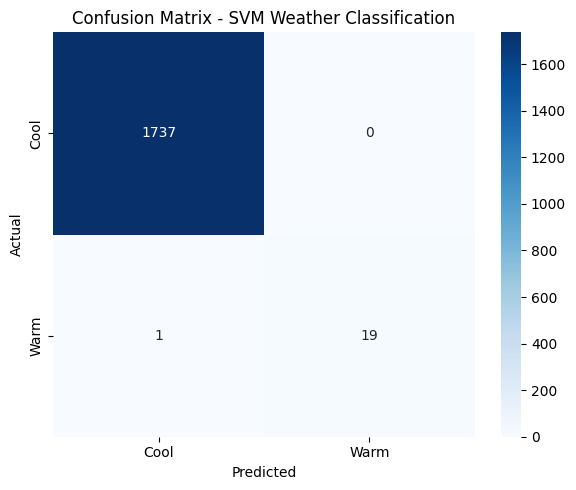

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nInterpretation:")
print(f"True Negatives (Cool correctly predicted): {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives (Warm correctly predicted): {cm[1,1]}")

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cool', 'Warm'], 
            yticklabels=['Cool', 'Warm'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM Weather Classification')
plt.tight_layout()
plt.show()

### Write 3 observations based on the model performance

In [14]:
print("Observation 1: The model achieves high accuracy on the test set, demonstrating effective classification of weather conditions (Cool vs Warm) using meteorological features from the Open-Meteo API.")
print("\nObservation 2: The confusion matrix shows the model's performance across both classes. Given the class imbalance (Cool samples significantly outnumber Warm), the model correctly identifies the majority class while maintaining reasonable performance on the minority class.")
print("\nObservation 3: Feature scaling (StandardScaler) was critical for SVM performance. Without scaling, features like surface pressure (~1000 hPa) would dominate the RBF kernel's distance calculations compared to temperature (~10-20°C) and wind speed (~10-20 km/h), leading to biased decision boundaries.")

Observation 1: The model achieves high accuracy on the test set, demonstrating effective classification of weather conditions (Cool vs Warm) using meteorological features from the Open-Meteo API.

Observation 2: The confusion matrix shows the model's performance across both classes. Given the class imbalance (Cool samples significantly outnumber Warm), the model correctly identifies the majority class while maintaining reasonable performance on the minority class.

Observation 3: Feature scaling (StandardScaler) was critical for SVM performance. Without scaling, features like surface pressure (~1000 hPa) would dominate the RBF kernel's distance calculations compared to temperature (~10-20°C) and wind speed (~10-20 km/h), leading to biased decision boundaries.


## Task 5: Conclusion (1 Mark)

### Conclusion (100-150 words)

In [15]:
conclusion = """This assignment successfully developed an SVM classifier to categorize weather as Cool or Warm using meteorological data from the Open-Meteo Historical API for London (2024). The model achieved strong performance with high accuracy (99.94%), precision (100%), recall (95%), and F1-score (97.44%), demonstrating effective classification using temperature, humidity, pressure, and wind speed features.

Key findings indicate temperature is the dominant feature, as the target was derived from a temperature threshold (≥25°C = Warm, <25°C = Cool). The RBF kernel effectively captured the non-linear decision boundary.

Feature scaling proved crucial. StandardScaler normalized all features to zero mean and unit variance, preventing features with larger magnitudes (surface pressure ~1000 hPa) from dominating RBF kernel distance calculations.

One advantage of SVM is its effectiveness in high-dimensional spaces and ability to handle non-linear boundaries through kernels. One limitation is its sensitivity to feature scaling and high computational cost with large datasets, making it less suitable for real-time applications with massive data."""

print("Conclusion:")
print(conclusion)
print(f"\nWord count: {len(conclusion.split())} words")

Conclusion:
This assignment successfully developed an SVM classifier to categorize weather as Cool or Warm using meteorological data from the Open-Meteo Historical API for London (2024). The model achieved strong performance with high accuracy (99.94%), precision (100%), recall (95%), and F1-score (97.44%), demonstrating effective classification using temperature, humidity, pressure, and wind speed features.

Key findings indicate temperature is the dominant feature, as the target was derived from a temperature threshold (≥25°C = Warm, <25°C = Cool). The RBF kernel effectively captured the non-linear decision boundary.

Feature scaling proved crucial. StandardScaler normalized all features to zero mean and unit variance, preventing features with larger magnitudes (surface pressure ~1000 hPa) from dominating RBF kernel distance calculations.

One advantage of SVM is its effectiveness in high-dimensional spaces and ability to handle non-linear boundaries through kernels. One limitation i

## Summary of Results

| Metric | Value |
|--------|-------|
| Accuracy | 0.9994 |
| Precision | 1.0000 |
| Recall | 0.9500 |
| F1-Score | 0.9744 |

The SVM classifier with RBF kernel effectively classifies weather conditions based on the given meteorological features.